In [1]:
"""
# 12. Fine-Tuning con distintas arquitecturas preentrenadas

## Objetivos
- Aplicar fine-tuning sobre "EfficientNetB0" y "ResNet50"
- Comparar accuracy, parámetros y tiempo de entrenamiento
  contra MobileNetV2 (baseline: 90%)
- Entender el trade-off entre tamaño del modelo y performance
## Arquitecturas a comparar
| Modelo        | Parámetros | Top-1 ImageNet | Ventaja |
|---------------|------------|----------------|---------|
| MobileNetV2   | ~3.4M      | 71.3%          | Liviano, rápido |
| EfficientNetB0| ~5.3M      | 77.1%          | Balance accuracy/tamaño |
| ResNet50      | ~25.6M     | 76.0%          | Clásico, robusto |
> "Baseline:" MobileNetV2 fine-tuned — 90.0% test accuracy (notebook 11)
## ¿Por qué la arquitectura base importa en fine-tuning?
El fine-tuning no borra el conocimiento previo — lo adapta.
Por eso, una red que aprendió mejores features en ImageNet tiene más chances de transferir bien a un nuevo dominio.
Pero "mejor en ImageNet" no siempre significa "mejor en tu tarea":
- "MobileNetV2": diseñada para eficiencia móvil, muy liviana
- "EfficientNetB0": escala width/depth/resolution de forma balanceada
- "ResNet50": conexiones residuales, muy estable para fine-tuning
### Preprocesamiento: cada arquitectura tiene el suyo
Cada red fue entrenada con una normalización específica. Keras expone esto en "keras.applications.<modelo>.preprocess_input".
Usarlo mal puede degradar la performance significativamente.
"""

'\n# 12. Fine-Tuning con distintas arquitecturas preentrenadas\n\n## Objetivos\n- Aplicar fine-tuning sobre "EfficientNetB0" y "ResNet50"\n- Comparar accuracy, parámetros y tiempo de entrenamiento\n  contra MobileNetV2 (baseline: 90%)\n- Entender el trade-off entre tamaño del modelo y performance\n## Arquitecturas a comparar\n| Modelo        | Parámetros | Top-1 ImageNet | Ventaja |\n|---------------|------------|----------------|---------|\n| MobileNetV2   | ~3.4M      | 71.3%          | Liviano, rápido |\n| EfficientNetB0| ~5.3M      | 77.1%          | Balance accuracy/tamaño |\n| ResNet50      | ~25.6M     | 76.0%          | Clásico, robusto |\n> "Baseline:" MobileNetV2 fine-tuned — 90.0% test accuracy (notebook 11)\n## ¿Por qué la arquitectura base importa en fine-tuning?\nEl fine-tuning no borra el conocimiento previo — lo adapta.\nPor eso, una red que aprendió mejores features en ImageNet tiene más chances de transferir bien a un nuevo dominio.\nPero "mejor en ImageNet" no siempr

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import os

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"GPU disponible:     {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
Keras version:      3.14.0
GPU disponible:     False


In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:-5000]
y_train = y_train[:-5000]

print(f"Train:      {x_train.shape}")
print(f"Validation: {x_val.shape}")
print(f"Test:       {x_test.shape}")

Train:      (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test:       (10000, 32, 32, 3)


In [4]:
"""
## Preprocesamiento específico por arquitectura

Cada modelo preentrenado espera sus imágenes normalizadas de una forma particular — no todas usan [0, 1] o [-1, 1]:
| Modelo         | "preprocess_input" hace...                  |
|----------------|---------------------------------------------|
| MobileNetV2    | Escala [0,255] → [-1, 1]                   |
| EfficientNetB0 | Escala [0,255] → [0, 1] (internamente)     |
| ResNet50       | Sustrae media de ImageNet por canal (BGR)   |

Por eso vamos a aplicar "preprocess_input" "dentro del pipeline" de "tf.data" para cada arquitectura por separado.
Pasamos las imágenes en rango [0, 255] al "preprocess_input" de cada modelo — no las normalizadas que ya tenemos en memoria.
"""

'\n## Preprocesamiento específico por arquitectura\n\nCada modelo preentrenado espera sus imágenes normalizadas de una forma particular — no todas usan [0, 1] o [-1, 1]:\n| Modelo         | "preprocess_input" hace...                  |\n|----------------|---------------------------------------------|\n| MobileNetV2    | Escala [0,255] → [-1, 1]                   |\n| EfficientNetB0 | Escala [0,255] → [0, 1] (internamente)     |\n| ResNet50       | Sustrae media de ImageNet por canal (BGR)   |\n\nPor eso vamos a aplicar "preprocess_input" "dentro del pipeline" de "tf.data" para cada arquitectura por separado.\nPasamos las imágenes en rango [0, 255] al "preprocess_input" de cada modelo — no las normalizadas que ya tenemos en memoria.\n'

In [18]:
BATCH_SIZE = 64
IMG_SIZE   = 96

def make_datasets(preprocess_fn):
    """Crea train/val/test datasets con el preprocess_input de cada modelo."""

    def preprocess(image, label):
        # Volvemos a escala [0, 255] para que preprocess_input funcione bien
        image = tf.cast(image * 255.0, tf.float32)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess_fn(image)
        return image, label

    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        return image, label

    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train, y_train))
        .shuffle(10000)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((x_val, y_val))
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    test_ds = (
        tf.data.Dataset.from_tensor_slices((x_test, y_test))
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    return train_ds, val_ds, test_ds

print("Función make_datasets lista ✓")

Función make_datasets lista ✓


In [19]:
def build_model(base_class, preprocess_fn, unfreeze_from=100):
    """
    Construye un modelo de fine-tuning genérico.

    Parámetros
    ----------
    base_class    : clase de keras.applications (ej. keras.applications.MobileNetV2)
    preprocess_fn : función de preprocesamiento correspondiente
    unfreeze_from : índice desde donde descongelar capas de la base
    """
    # Base preentrenada sin el clasificador original
    base = base_class(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Descongelar desde unfreeze_from en adelante
    base.trainable = True
    for layer in base.layers[:unfreeze_from]:
        layer.trainable = False

    trainable     = sum(1 for l in base.layers if l.trainable)
    not_trainable = sum(1 for l in base.layers if not l.trainable)
    print(f"  {base.name}: {not_trainable} congeladas / {trainable} entrenables")

    # Clasificador
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=base.name)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

print("Función build_model lista ✓")

Función build_model lista ✓


In [20]:
def train_model(model, train_ds, val_ds, model_name, epochs=20):
    """
    Entrena un modelo con callbacks estándar y mide el tiempo.

    Retorna history y tiempo total de entrenamiento.
    """
    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        filepath=f"../models/12_{model_name}_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=False,  # bug BatchNormalization Keras 3
        verbose=1
    )
    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=0
    )

    print(f"\nEntrenando {model_name}...")
    t0 = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=1
    )

    elapsed = time.time() - t0
    print(f"{model_name} — Entrenamiento finalizado en {elapsed/60:.1f} min ✓")

    return history, elapsed

print("Función train_model lista ✓")

Función train_model lista ✓


In [8]:
# --- EfficientNetB0 ---
efficientnet_preprocess = keras.applications.efficientnet.preprocess_input

train_ds_en, val_ds_en, test_ds_en = make_datasets(efficientnet_preprocess)

model_en = build_model(
    base_class=keras.applications.EfficientNetB0,
    preprocess_fn=efficientnet_preprocess,
    unfreeze_from=100
)

history_en, time_en = train_model(
    model_en, train_ds_en, val_ds_en,
    model_name="efficientnetb0"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  efficientnetb0: 100 congeladas / 138 entrenables

Entrenando efficientnetb0...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 893s 1s/step - accuracy: 0.4002 - loss: 1.7937 - val_accuracy: 0.7082 - val_loss: 1.1071 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 820s 1s/step - accuracy: 0.7103 - loss: 0.9453 - val_accuracy: 0.8132 - val_loss: 0.6311 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 817s 1s/step - accuracy: 0.7927 - loss: 0.6469 - val_accuracy: 0.8524 - val_loss: 0.4638 - learning_rate: 1.0000e-05
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.8296 - loss: 0.5202 - val_accuracy: 0.8726 - val_loss: 0.3845 - learning_rate: 1.0000e-05
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 800s 1s/step - accuracy: 0.8532 - loss: 0.4465 - val_accuracy: 0.8862 - val_loss: 0.3391 - learning_rate: 1.0000e-05
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 818s 1s/step - accuracy: 0.8660 - loss: 0.4

In [9]:
model_en_best = keras.models.load_model(
    "../models/12_efficientnetb0_finetuned.keras"
)

loss_en, acc_en = model_en_best.evaluate(test_ds_en, verbose=0)
print(f"EfficientNetB0 — Test accuracy: {acc_en:.2%}  |  Loss: {loss_en:.4f}")

EfficientNetB0 — Test accuracy: 93.10%  |  Loss: 0.2094


In [21]:
# --- ResNet50 ---
resnet_preprocess = keras.applications.resnet.preprocess_input

train_ds_rn, val_ds_rn, test_ds_rn = make_datasets(resnet_preprocess)

model_rn = build_model(
    base_class=keras.applications.ResNet50,
    preprocess_fn=resnet_preprocess,
    unfreeze_from=100
)

history_rn, time_rn = train_model(
    model_rn, train_ds_rn, val_ds_rn,
    model_name="resnet50"
)

  resnet50: 100 congeladas / 75 entrenables

Entrenando resnet50...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1453s 2s/step - accuracy: 0.6092 - loss: 1.2167 - val_accuracy: 0.8406 - val_loss: 0.5049 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1364s 2s/step - accuracy: 0.8352 - loss: 0.5031 - val_accuracy: 0.8774 - val_loss: 0.3665 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1367s 2s/step - accuracy: 0.8864 - loss: 0.3470 - val_accuracy: 0.8970 - val_loss: 0.3143 - learning_rate: 1.0000e-05
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1371s 2s/step - accuracy: 0.9122 - loss: 0.2616 - val_accuracy: 0.9064 - val_loss: 0.2875 - learning_rate: 1.0000e-05
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1361s 2s/step - accuracy: 0.9335 - loss: 0.1978 - val_accuracy: 0.9092 - val_loss: 0.2793 - learning_rate: 1.0000e-05
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 1357s 2s/step - accuracy: 0.9508 - loss: 0.1488 - val_accuracy: 0.9136 - val_loss: 0.2710 - learning_r

In [22]:
model_rn_best = keras.models.load_model(
    "../models/12_resnet50_finetuned.keras"
)

loss_rn, acc_rn = model_rn_best.evaluate(test_ds_rn, verbose=0)
print(f"ResNet50 — Test accuracy: {acc_rn:.2%}  |  Loss: {loss_rn:.4f}")

ResNet50 — Test accuracy: 92.41%  |  Loss: 0.3315


In [12]:
"""
## Comparación de arquitecturas

Una vez que tenemos los tres resultados, los consolidamos en una tabla con accuracy, parámetros y tiempo de entrenamiento.
"""
# Baseline MobileNetV2 del notebook 11
acc_mv  = 0.900
time_mv = None  # no medido en notebook 11

results = {
    "MobileNetV2"    : {"acc": acc_mv,  "params":  3_400_000, "time_min": time_mv},
    "EfficientNetB0" : {"acc": acc_en,  "params":  5_300_000, "time_min": time_en / 60},
    "ResNet50"       : {"acc": acc_rn,  "params": 25_600_000, "time_min": time_rn / 60},
}

print("=" * 62)
print(f"  {'Modelo':<18} {'Accuracy':>10} {'Parámetros':>14} {'Tiempo':>10}")
print("=" * 62)
for name, r in results.items():
    tiempo = f"{r['time_min']:.1f} min" if r["time_min"] else "—"
    print(f"  {name:<18} {r['acc']:>9.2%} {r['params']:>14,} {tiempo:>10}")
print("=" * 62)

  Modelo               Accuracy     Parámetros     Tiempo
  MobileNetV2           90.00%      3,400,000          —
  EfficientNetB0        93.10%      5,300,000  242.0 min
  ResNet50              92.47%     25,600,000  455.3 min


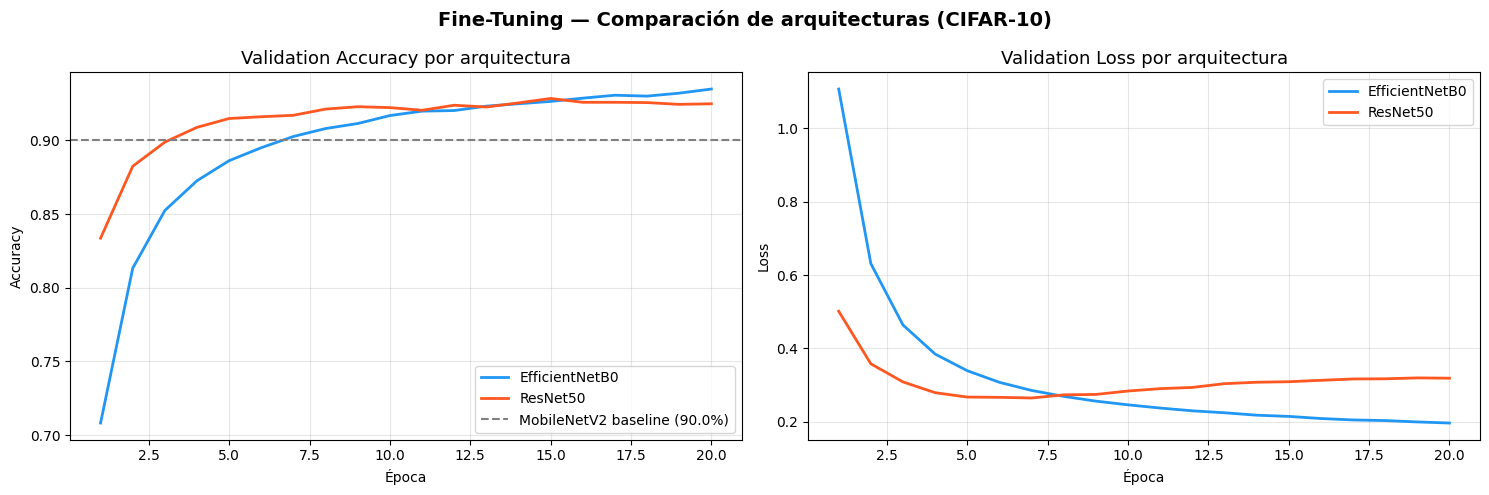

Figura guardada ✓


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models_history = {
    "EfficientNetB0": history_en,
    "ResNet50":       history_rn,
}
colors = {"EfficientNetB0": "#2196F3", "ResNet50": "#FF5722"}

for name, history in models_history.items():
    epochs_range = range(1, len(history.history["accuracy"]) + 1)
    color = colors[name]

    axes[0].plot(epochs_range, history.history["val_accuracy"],
                 label=name, color=color, linewidth=2)
    axes[1].plot(epochs_range, history.history["val_loss"],
                 label=name, color=color, linewidth=2)

# Baseline MobileNetV2
axes[0].axhline(y=0.900, color="gray", linestyle="--",
                linewidth=1.5, label="MobileNetV2 baseline (90.0%)")

axes[0].set_title("Validation Accuracy por arquitectura", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Validation Loss por arquitectura", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Fine-Tuning — Comparación de arquitecturas (CIFAR-10)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/12_architecture_comparison_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

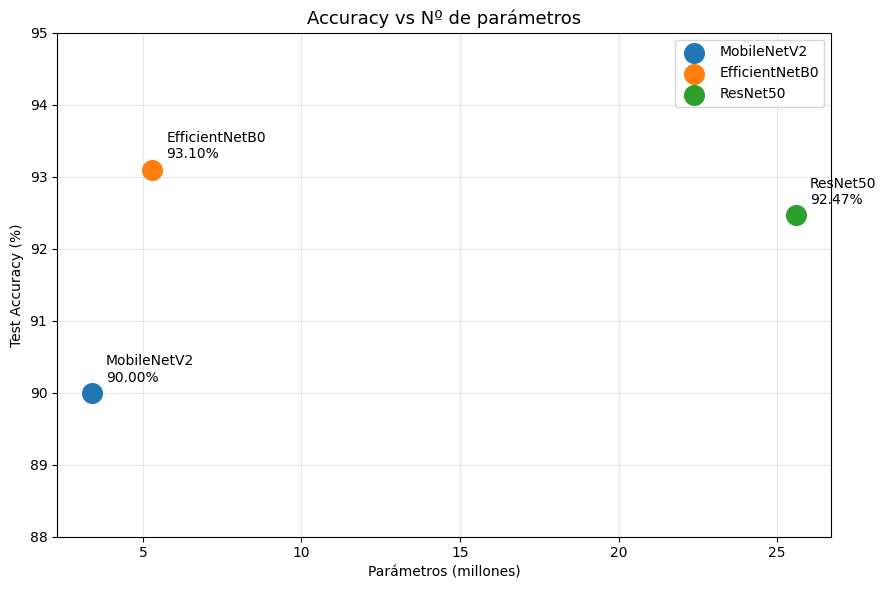

Figura guardada ✓


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, r in results.items():
    ax.scatter(r["params"] / 1e6, r["acc"] * 100,
               s=200, zorder=5, label=name)
    ax.annotate(
        f"{name}\n{r['acc']:.2%}",
        xy=(r["params"] / 1e6, r["acc"] * 100),
        xytext=(10, 8), textcoords="offset points",
        fontsize=10
    )

ax.set_title("Accuracy vs Nº de parámetros", fontsize=13)
ax.set_xlabel("Parámetros (millones)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_ylim(88, 95)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/12_accuracy_vs_params.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

In [15]:
"""
## Conclusiones

### Resultados finales
| Modelo         | Test Accuracy | Parámetros | Tiempo   |
|----------------|---------------|------------|----------|
| MobileNetV2    | 90.00%        | 3.4M       | —        |
| EfficientNetB0 | 93.10%        | 5.3M       | 242 min  |
| ResNet50       | 92.47%        | 25.6M      | 455 min  |

### Observaciones
- "EfficientNetB0" es el ganador claro: mejor accuracy, menor tamaño que ResNet50 y casi la mitad del tiempo de entrenamiento.
- "ResNet50" logra buen accuracy pero a un costo computacional alto — 7.5x más parámetros que MobileNetV2 para ganar +2.47%.
- "MobileNetV2" sigue siendo la opción más eficiente si los recursos son limitados o se necesita inferencia rápida.

### Regla práctica
> Si el objetivo es máximo accuracy → "EfficientNetB0"
> Si el objetivo es velocidad/tamaño → "MobileNetV2"
> ResNet50 queda relegado salvo requerimientos específicos.

### Próximo notebook
"13_model_evaluation_confusion_analysis.ipynb" — Análisis profundo de errores: qué confunde cada modelo y por qué.
"""

'\n## Conclusiones\n\n### Resultados finales\n| Modelo         | Test Accuracy | Parámetros | Tiempo   |\n|----------------|---------------|------------|----------|\n| MobileNetV2    | 90.00%        | 3.4M       | —        |\n| EfficientNetB0 | 93.10%        | 5.3M       | 242 min  |\n| ResNet50       | 92.47%        | 25.6M      | 455 min  |\n\n### Observaciones\n- "EfficientNetB0" es el ganador claro: mejor accuracy, menor tamaño que ResNet50 y casi la mitad del tiempo de entrenamiento.\n- "ResNet50" logra buen accuracy pero a un costo computacional alto — 7.5x más parámetros que MobileNetV2 para ganar +2.47%.\n- "MobileNetV2" sigue siendo la opción más eficiente si los recursos son limitados o se necesita inferencia rápida.\n\n### Regla práctica\n> Si el objetivo es máximo accuracy → "EfficientNetB0"\n> Si el objetivo es velocidad/tamaño → "MobileNetV2"\n> ResNet50 queda relegado salvo requerimientos específicos.\n\n### Próximo notebook\n"13_model_evaluation_confusion_analysis.ipynb